In [4]:
import model_template as model
import pandas as pd
import numpy as np
import pollux as plx
from pollux.models.transforms import LinearTransform
import matplotlib.pyplot as plt
from matplotlib import rcParams
import time

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [2]:
datafile_path = '/Users/honeyeah/Codes/LuxProject/data/giants_rel_most_rel.pkl'
df_stars = pd.read_pickle(datafile_path)
n_stars = 500
n_latents = 20
labels = ['teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 'ni_h', 'ca_h', 'ce_h']

In [3]:
results = []
deltats = []
rmses = []
n_latents = []

for i in range(15,20):
    t0 = time.time()
    predict_train_values, train_data, predict_test_values, test_data, predict_test_values_flux, all_data = model.sdss_gaia_model(
        path_to_pickle=datafile_path,
        label_names=labels,
        n_stars=n_stars,
        n_latents=i,
        which_output='all'
    )
    deltat = time.time() - t0
    deltats.append(deltat)
    predict_test_unprocessed = test_data.unprocess(predict_test_values_flux)
    test_data_unprocessed = all_data[n_stars // 2:]
    total_rmse = np.sqrt(np.mean((predict_test_unprocessed["label"].data - test_data_unprocessed["label"].data) ** 2))
    rmses.append(total_rmse)
    n_latents.append(i)

KeyboardInterrupt: 

In [ ]:
predict_test_unprocessed = test_data.unprocess(predict_test_values_flux)
test_data_unprocessed = all_data[n_stars // 2:]

results = {}

for i, name in enumerate(labels):
    y_true = test_data_unprocessed["label"].data[:, i]
    y_pred = predict_test_unprocessed["label"].data[:, i]

    res = y_pred - y_true

    results[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "residuals": res,
        "std_res": np.std(res),
        "RMSE": np.sqrt(np.mean(res**2)),
        "MAE": np.mean(np.abs(res)),
        "Bias": np.mean(res),
        "R2": 1 - np.sum(res**2) / np.sum((y_true - np.mean(y_true))**2),
    }

total_rmse = np.sqrt(np.mean((predict_test_unprocessed["label"].data - test_data_unprocessed["label"].data) ** 2))

In [5]:
results_n_latents = pd.read_csv("latent_scan_results_2.csv")
results_n_latents.head()

,n_latent,delta_t,rmse,rmse_teff,rmse_logg,rmse_fe_h,rmse_mg_h,rmse_n_h,rmse_si_h,rmse_ni_h,rmse_ca_h,rmse_ce_h
0,12,59.367141,31.915313,95.744370,0.195248,0.083694,0.086284,0.336361,0.095022,0.209072,0.116829,0.261004
1,13,71.096290,34.091566,102.273559,0.173354,0.078363,0.079157,0.231371,0.084441,0.221817,0.112183,0.260519
2,14,60.543675,34.298667,102.894833,0.170926,0.078516,0.078770,0.242226,0.086463,0.225428,0.113140,0.263117
3,15,60.279127,34.430380,103.290004,0.169695,0.077948,0.078570,0.239481,0.084739,0.222742,0.114153,0.257764
4,16,62.656447,34.625095,103.874189,0.170645,0.078875,0.078820,0.223923,0.086823,0.218689,0.114994,0.259255


In [6]:
min_idx = results_n_latents['rmse'].idxmin()
best_n_latent = results_n_latents.loc[min_idx]

print(best_n_latent)

n_latent     12.000000
delta_t      59.367141
rmse         31.915313
rmse_teff    95.744370
rmse_logg     0.195248
rmse_fe_h     0.083694
rmse_mg_h     0.086284
rmse_n_h      0.336361
rmse_si_h     0.095022
rmse_ni_h     0.209072
rmse_ca_h     0.116829
rmse_ce_h     0.261004
Name: 0, dtype: float64


In [7]:
best3 = results_n_latents.nsmallest(3, 'rmse')

best3

,n_latent,delta_t,rmse,rmse_teff,rmse_logg,rmse_fe_h,rmse_mg_h,rmse_n_h,rmse_si_h,rmse_ni_h,rmse_ca_h,rmse_ce_h
0,12,59.367141,31.915313,95.744370,0.195248,0.083694,0.086284,0.336361,0.095022,0.209072,0.116829,0.261004
9,21,65.721750,32.811475,98.433255,0.166978,0.078437,0.079629,0.232627,0.085231,0.218857,0.114711,0.259897
6,18,63.864140,32.873173,98.618315,0.167279,0.078400,0.078843,0.245034,0.084836,0.219290,0.116637,0.260839


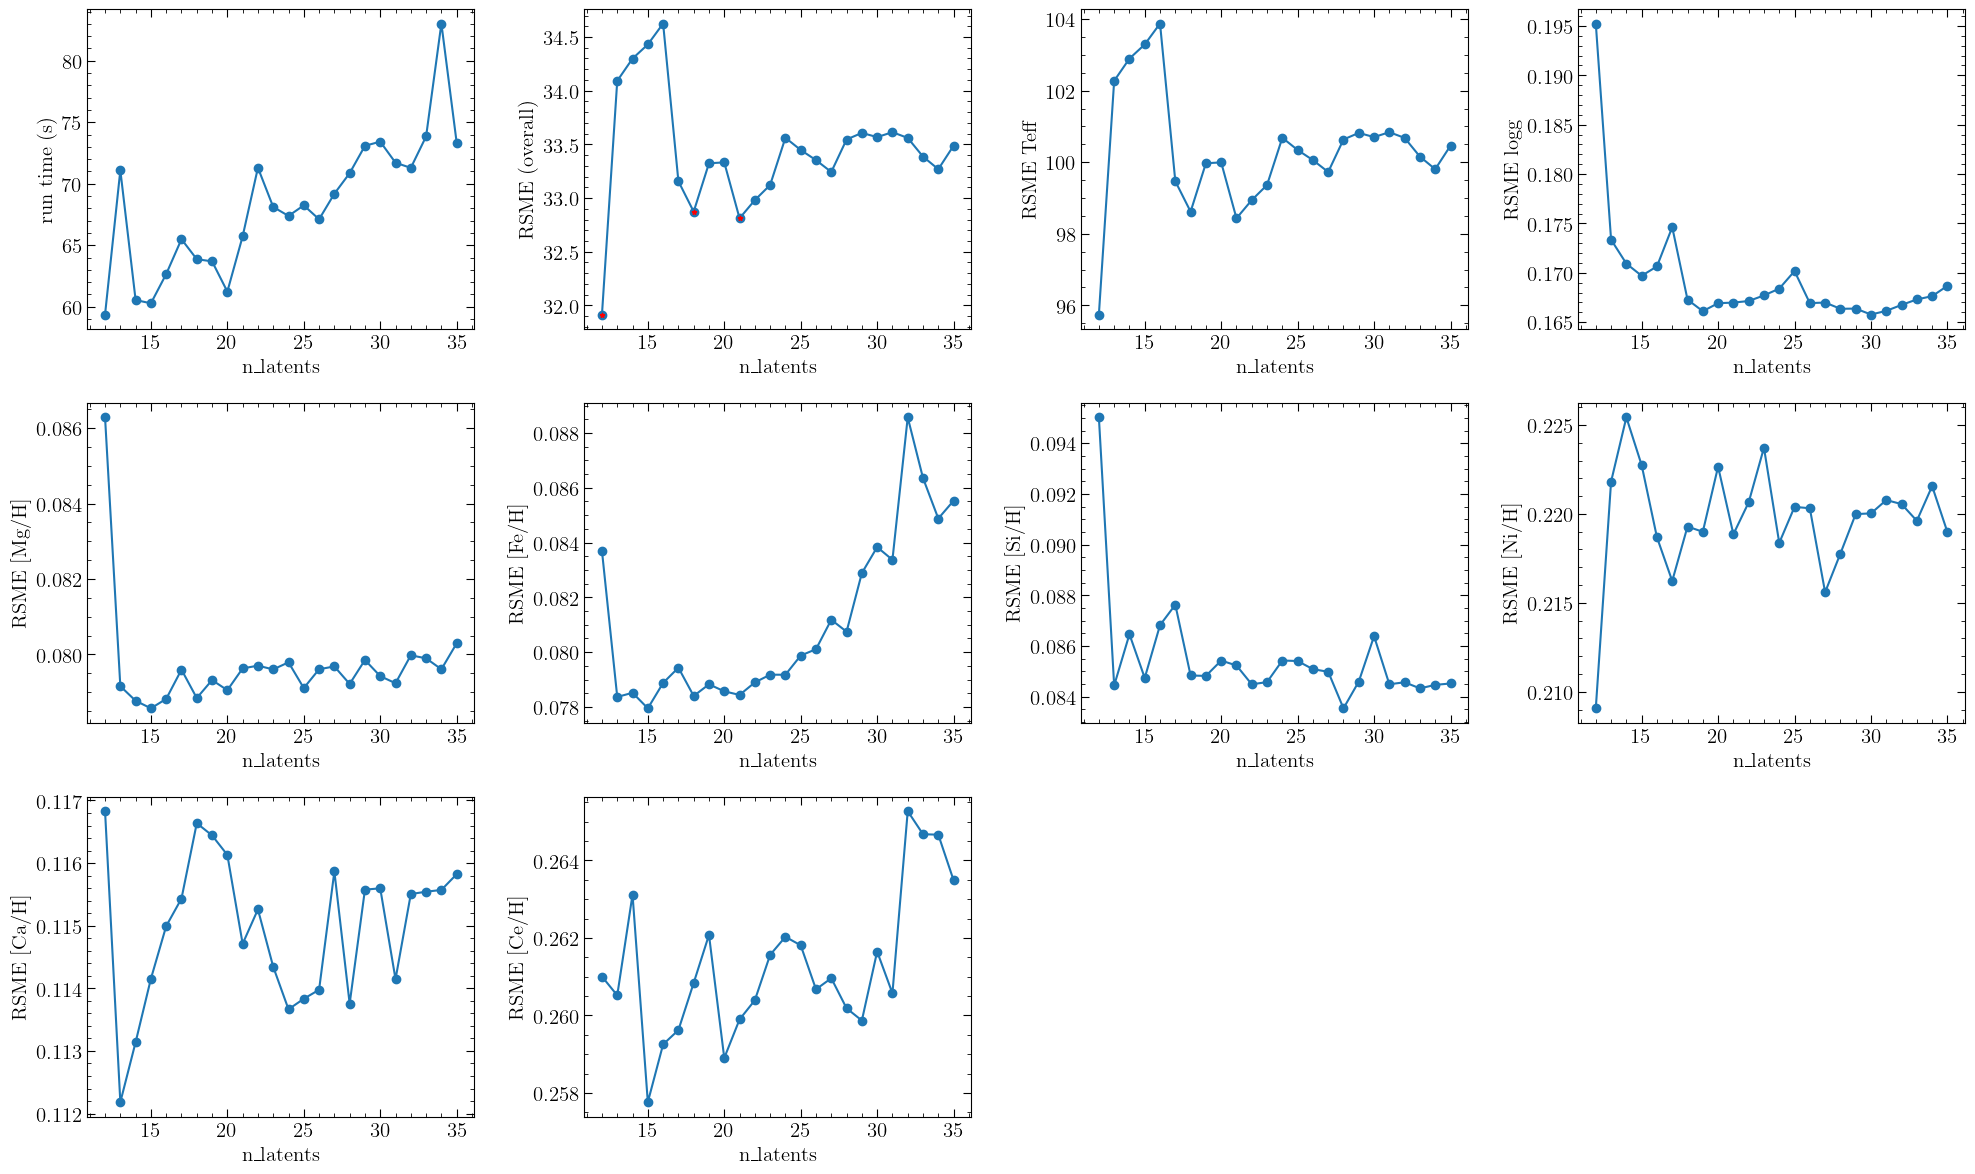

In [8]:
n_rows = 3
n_cols = 4
plt.figure(figsize=(20,12))

plt.subplot(3,n_cols,1)
plt.plot(results_n_latents['n_latent'], results_n_latents['delta_t'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("run time (s)")

plt.subplot(3,n_cols,2)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME (overall)")
plt.scatter(best3['n_latent'], best3['rmse'], marker='*', s=10, color = 'red', zorder=5)

plt.subplot(3,n_cols,3)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_teff'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME Teff")

plt.subplot(3,n_cols,4)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_logg'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME logg")

plt.subplot(3,n_cols,5)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_mg_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Mg/H]")

plt.subplot(3,n_cols,6)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_fe_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Fe/H]")

plt.subplot(3,n_cols,7)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_si_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Si/H]")

plt.subplot(3,n_cols,8)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ni_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Ni/H]")

plt.subplot(3,n_cols,9)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ca_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Ca/H]")

plt.subplot(3,n_cols,10)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ce_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Ce/H]")

plt.tight_layout()

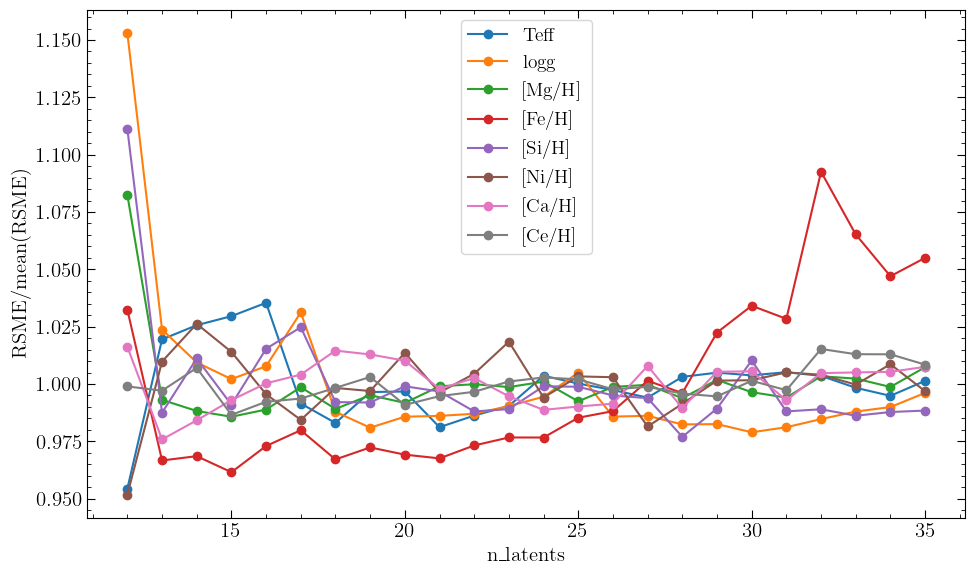

In [9]:
plt.figure(figsize=(10,6))


plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_teff']/np.mean(results_n_latents['rmse_teff']), marker='o', label = 'Teff')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_logg']/np.mean(results_n_latents['rmse_logg']), marker='o', label = 'logg')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_mg_h']/np.mean(results_n_latents['rmse_mg_h']), marker='o', label = '[Mg/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_fe_h']/np.mean(results_n_latents['rmse_fe_h']), marker='o', label = '[Fe/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_si_h']/np.mean(results_n_latents['rmse_si_h']), marker='o', label = '[Si/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ni_h']/np.mean(results_n_latents['rmse_ni_h']), marker='o', label = '[Ni/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ca_h']/np.mean(results_n_latents['rmse_ca_h']), marker='o', label = '[Ca/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ce_h']/np.mean(results_n_latents['rmse_ce_h']), marker='o', label = '[Ce/H]')

plt.legend()

plt.xlabel("n_latents")
plt.ylabel("RSME/mean(RSME)")
plt.tight_layout()

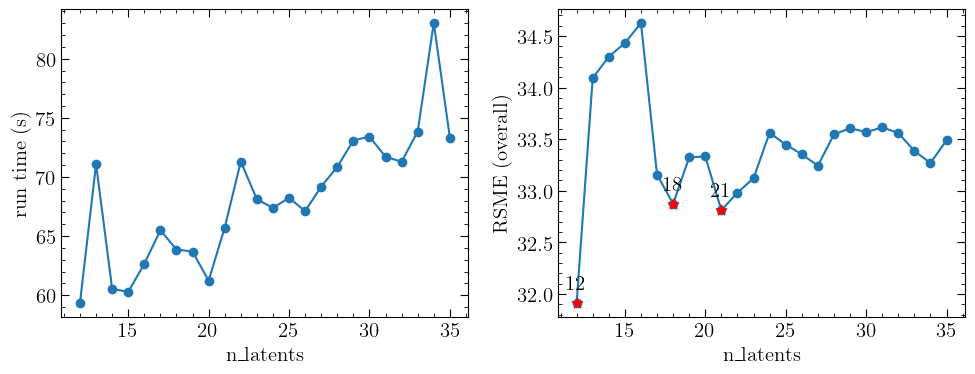

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(results_n_latents['n_latent'], results_n_latents['delta_t'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("run time (s)")

plt.subplot(1,2,2)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME (overall)")
plt.scatter(best3['n_latent'], best3['rmse'], marker='*', s=60, color = 'red', zorder=5)
for _, row in best3.iterrows():
    plt.annotate(
        text=f"{int(row['n_latent'])}",
        xy=(row['n_latent'], row['rmse']),
        xytext=(0, 10),                 # offset text slightly above
        textcoords="offset points",
        ha='center'
    )

plt.tight_layout()

In [11]:
# Columns to include in global metric
rmse_cols = [
    'rmse_teff',
    'rmse_logg',
    'rmse_fe_h',
    'rmse_mg_h',
    'rmse_si_h',
    'rmse_ni_h',
    'rmse_ca_h'
]

# --- Normalize by column mean ---
norm_factors = results_n_latents[rmse_cols].mean()

normalized = results_n_latents[rmse_cols] / norm_factors

# --- Aggregate (RMS across labels) ---
results_n_latents['rmse_global_norm'] = np.sqrt(
    (normalized ** 2).mean(axis=1)
)

# --- Sort and inspect ---
results_sorted = results_n_latents.sort_values('rmse_global_norm')

best1 = results_sorted.iloc[0]
best3 = results_sorted.head(3)

print("Best configuration:")
print(best1[['n_latent','rmse_global_norm']])
print("\nTop 3:")
print(best3[['n_latent','rmse_global_norm']])

Best configuration:
n_latent            21.000000
rmse_global_norm     0.989286
Name: 9, dtype: float64

Top 3:
    n_latent  rmse_global_norm
9         21          0.989286
6         18          0.990375
16        28          0.990474


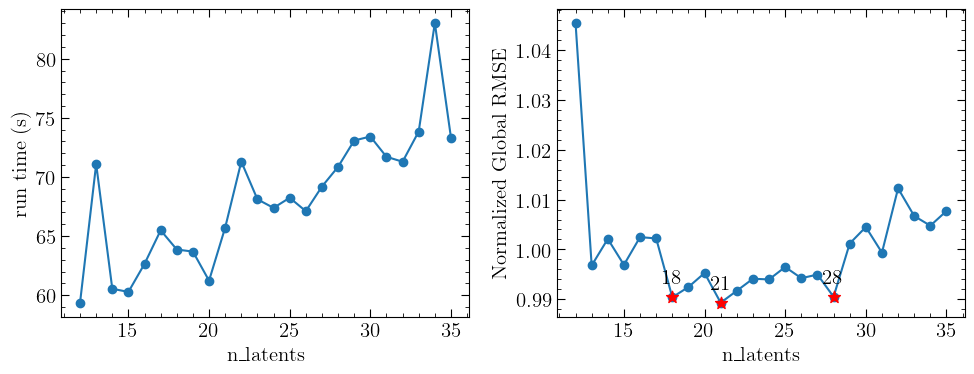

In [12]:
plt.figure(figsize=(10,4))

# --- Runtime ---
plt.subplot(1,2,1)
plt.plot(results_n_latents['n_latent'],
         results_n_latents['delta_t'],
         marker='o')
plt.xlabel("n_latents")
plt.ylabel("run time (s)")

# --- Normalized Global RMSE ---
plt.subplot(1,2,2)
plt.plot(results_n_latents['n_latent'],
         results_n_latents['rmse_global_norm'],
         marker='o')

plt.xlabel("n_latents")
plt.ylabel("Normalized Global RMSE")

# highlight best 3
plt.scatter(best3['n_latent'],
            best3['rmse_global_norm'],
            marker='*',
            s=80,
            color='red',
            zorder=5)

for _, row in best3.iterrows():
    plt.annotate(
        text=f"{int(row['n_latent'])}",
        xy=(row['n_latent'], row['rmse_global_norm']),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center'
    )

plt.tight_layout()
